In [1]:
# Author: Arun Bamal
# Project: Data Engineering Assignmentimport duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("ecommerce.db")

print("Ready for visualization")

Ready for visualization


In [2]:
df_category = con.execute("""
SELECT 
    category_code,
    SUM(price) AS revenue
FROM clean_events
WHERE event_type = 'purchase'
GROUP BY category_code
ORDER BY revenue DESC
LIMIT 10
""").fetchdf()

df_category

,category_code,revenue
0,electronics.smartphone,1.570496e+08
1,NaN,2.292494e+07
2,computers.notebook,8.979887e+06
3,electronics.video.tv,8.423408e+06
4,electronics.clocks,4.818305e+06
5,appliances.kitchen.washer,4.658647e+06
6,appliances.kitchen.refrigerators,3.830077e+06
7,electronics.audio.headphone,3.539127e+06
8,appliances.environment.vacuum,1.716425e+06
9,electronics.tablet,1.610974e+06


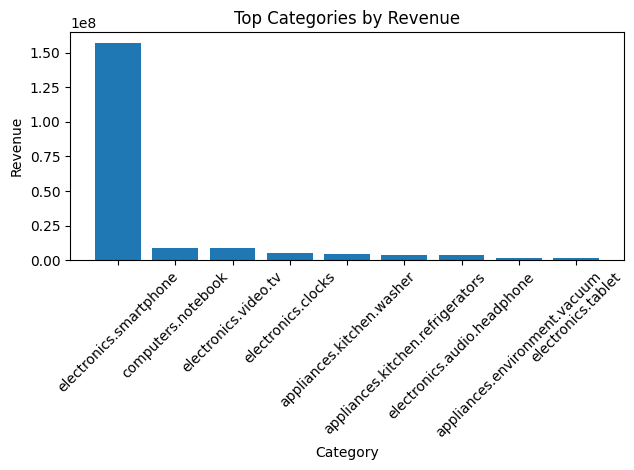

In [4]:

df_category = df_category.dropna(subset=["category_code"])

df_category["category_code"] = df_category["category_code"].astype(str)

plt.figure()
plt.bar(df_category["category_code"], df_category["revenue"])

plt.xticks(rotation=45)
plt.title("Top Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [5]:
df_daily = con.execute("""
SELECT 
    DATE(event_time) AS date,
    SUM(price) AS revenue
FROM clean_events
WHERE event_type = 'purchase'
GROUP BY date
ORDER BY date
""").fetchdf()

df_daily

,date,revenue
0,2019-10-01,6275964.01
1,2019-10-02,6213628.53
2,2019-10-03,6233782.98
3,2019-10-04,8623684.47
4,2019-10-05,7341596.91
5,2019-10-06,6737660.78
6,2019-10-07,6348189.06
7,2019-10-08,6819832.28
8,2019-10-09,6855511.13
9,2019-10-10,6665600.86


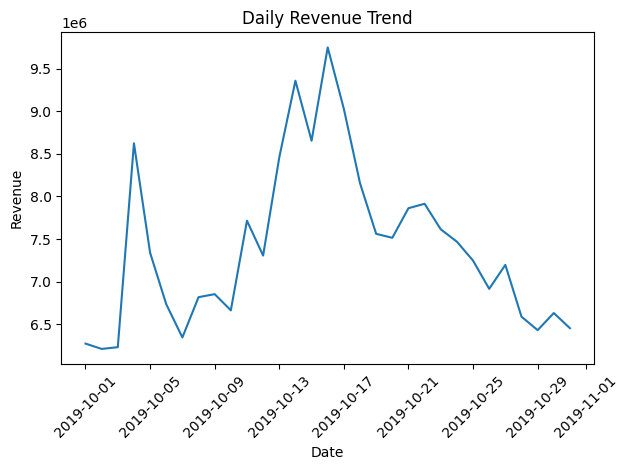

In [6]:
plt.figure()
plt.plot(df_daily["date"], df_daily["revenue"])
plt.xticks(rotation=45)
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [7]:
df_events = con.execute("""
SELECT 
    event_type,
    COUNT(*) AS total
FROM clean_events
GROUP BY event_type
""").fetchdf()

df_events

,event_type,total
0,cart,926516
1,view,40779399
2,purchase,742849


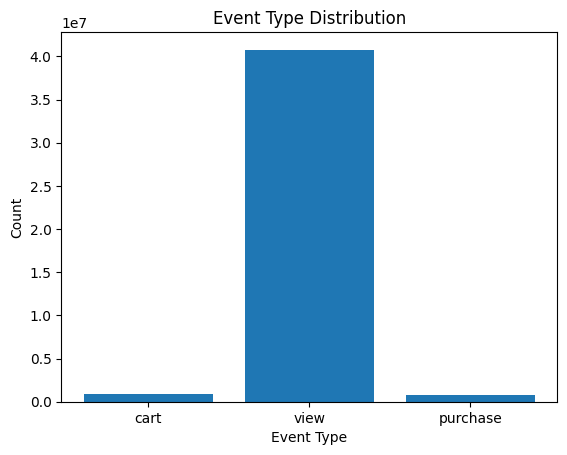

In [8]:
plt.figure()
plt.bar(df_events["event_type"], df_events["total"])
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

In [9]:
df_brands = con.execute("""
SELECT 
    brand,
    SUM(price) AS revenue
FROM clean_events
WHERE event_type = 'purchase'
    AND brand IS NOT NULL
GROUP BY brand
ORDER BY revenue DESC
LIMIT 10
""").fetchdf()

df_brands

,brand,revenue
0,apple,1.112093e+08
1,samsung,4.640753e+07
2,xiaomi,9.194033e+06
3,huawei,4.883422e+06
4,acer,3.576720e+06
5,lg,3.387888e+06
6,lucente,3.124113e+06
7,sony,2.478197e+06
8,oppo,2.412960e+06
9,lenovo,1.752639e+06


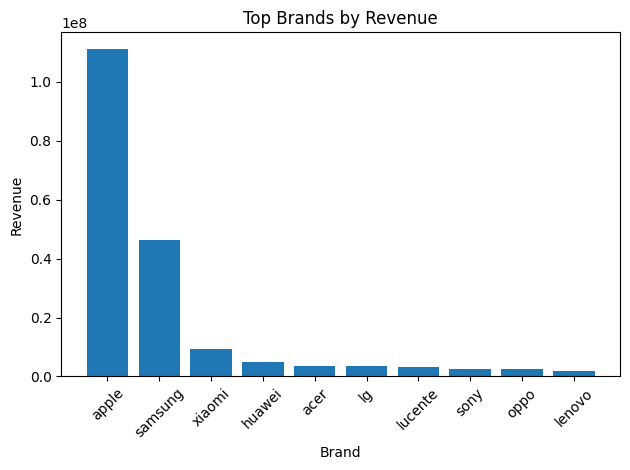

In [10]:
plt.figure()
plt.bar(df_brands["brand"], df_brands["revenue"])
plt.xticks(rotation=45)
plt.title("Top Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

Plot saved as category_revenue.png


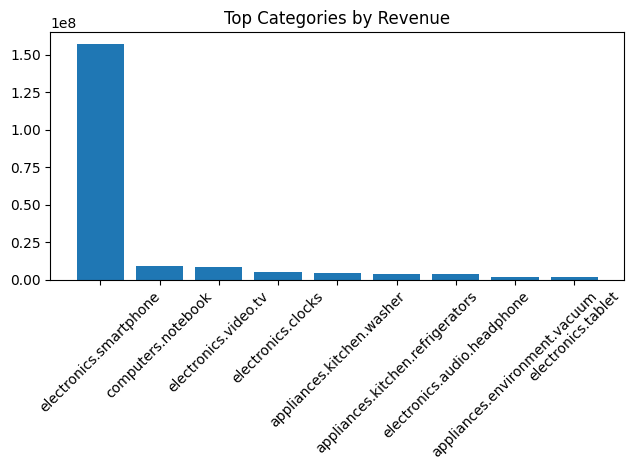

In [11]:
plt.figure()
plt.bar(df_category["category_code"], df_category["revenue"])
plt.xticks(rotation=45)
plt.title("Top Categories by Revenue")
plt.tight_layout()

plt.savefig("category_revenue.png")

print("Plot saved as category_revenue.png")

In [12]:
con.close()